# Telco Customer Churn EDA

This notebook is a lightweight exploratory companion to the training pipeline. All production feature engineering is implemented in `scripts/preprocessing.py` so it is reproduced at inference time.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = pd.read_csv(DATA_PATH)
df.shape, df.dtypes

((7043, 21),
 customerID              str
 gender                  str
 SeniorCitizen         int64
 Partner                 str
 Dependents              str
 tenure                int64
 PhoneService            str
 MultipleLines           str
 InternetService         str
 OnlineSecurity          str
 OnlineBackup            str
 DeviceProtection        str
 TechSupport             str
 StreamingTV             str
 StreamingMovies         str
 Contract                str
 PaperlessBilling        str
 PaymentMethod           str
 MonthlyCharges      float64
 TotalCharges            str
 Churn                   str
 dtype: object)

In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Mistyped Columns

`TotalCharges` is mistyped as `object` because several rows contain blank strings. It should be converted with `pd.to_numeric(..., errors='coerce')` and imputed inside the Pipeline.

In [3]:
df['Churn'].value_counts(normalize=True).rename('share')

Churn
No     0.73463
Yes    0.26537
Name: share, dtype: float64

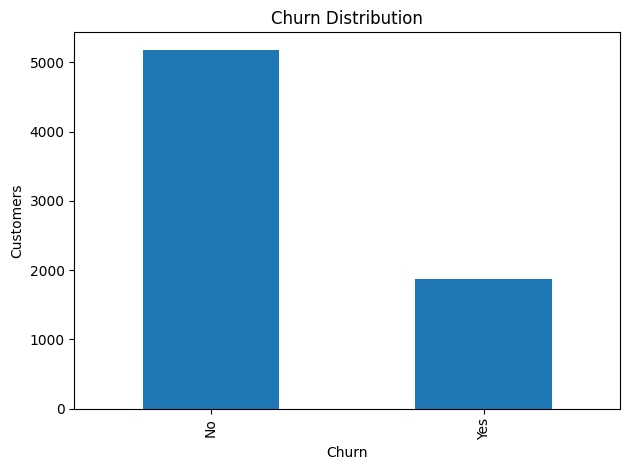

In [4]:
df['Churn'].value_counts().plot(kind='bar', title='Churn Distribution')
plt.ylabel('Customers')
plt.tight_layout()

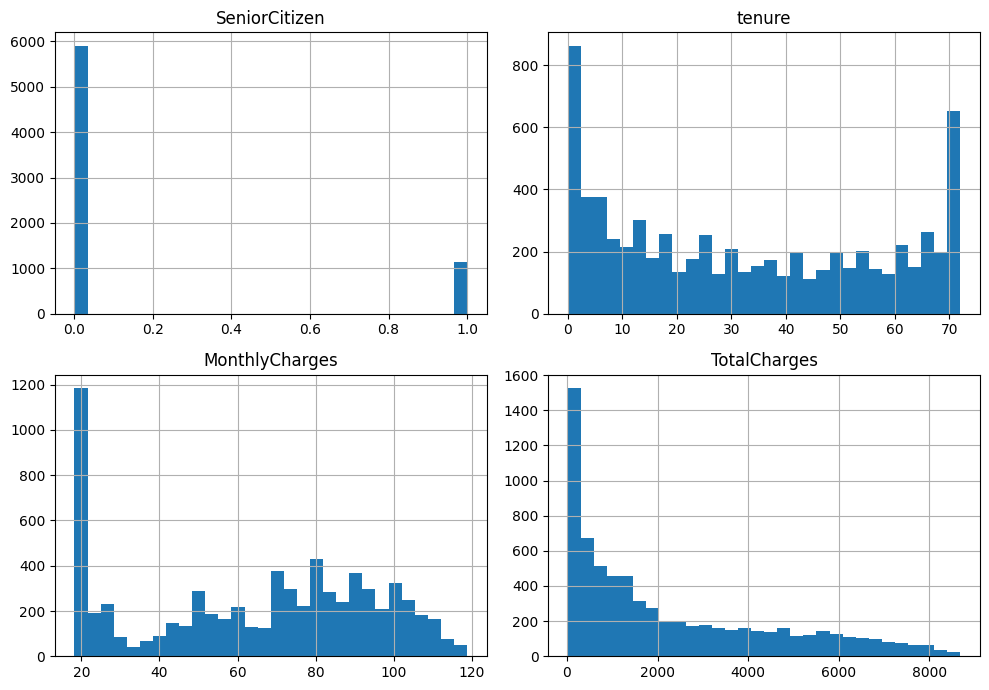

In [5]:
eda_df = df.copy()
eda_df['TotalCharges'] = pd.to_numeric(eda_df['TotalCharges'], errors='coerce')
numeric_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
eda_df[numeric_cols].hist(figsize=(10, 7), bins=30)
plt.tight_layout()

In [6]:
missing_report = pd.DataFrame({
    'explicit_na': df.isna().sum(),
    'blank_strings': df.astype(str).apply(lambda s: s.str.strip().eq('').sum()),
})
missing_report[missing_report.sum(axis=1) > 0]

,explicit_na,blank_strings
TotalCharges,0,11


In [7]:
for col in ['Contract', 'PaymentMethod', 'InternetService']:
    display(pd.crosstab(df[col], df['Churn'], normalize='index').round(3))

Churn,No,Yes
Contract,,
Month-to-month,0.573,0.427
One year,0.887,0.113
Two year,0.972,0.028


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.833,0.167
Credit card (automatic),0.848,0.152
Electronic check,0.547,0.453
Mailed check,0.809,0.191


Churn,No,Yes
InternetService,,
DSL,0.810,0.190
Fiber optic,0.581,0.419
No,0.926,0.074


## Initial Insights

- Month-to-month customers churn much more often than one-year or two-year contract customers.
- Electronic check users show elevated churn compared with mailed check or automatic payment methods.
- Fiber optic internet customers have higher churn than DSL customers, suggesting plan cost, competition, or service quality may matter.